# Principal Component Analysis

### Theory
* Unsupervised statistical technique used to examine the interrelations among a set of variables in order to identify the structure of those variables
* Sometimes also known as general factor analysis
* In an essence, it is a way to reduce dimensionality (reducing the number of columns, while keeping the most relevant or useful information)

<b>Diving Further</b>
* Regression analysis determines a line of best fit to the data
* Factor analysis determines several orthogonal lines of best fit to the data
* Orthogonal means "at right angles"
  * The lines are perpendicular to each other in n-dimensional space
* n-Dimensional Space is the variable sample space
  * There are as many dimensions as there are variables, so in a dataset with 4 variables, the sample space is 4-dimensional

<b>More than just removing columns</b>
* Find patterns in the data: It looks for directions in your data where there’s the most variation (i.e., where the data spreads out the most).
* Create new features: It creates new columns (called principal components) that are combinations of your original columns — these new features represent the same data in fewer dimensions.
* Keep the most important ones: You keep only the top few new features that capture most of the information (the ones that explain the most variance in the dataset).

<div>
    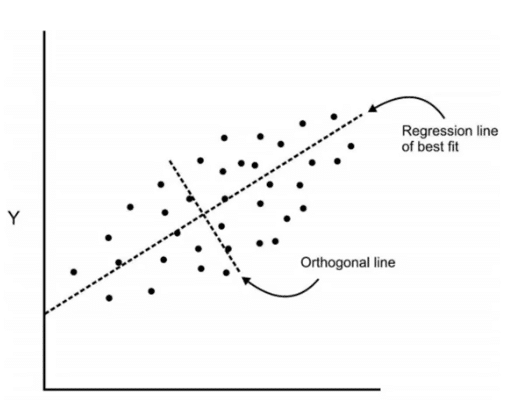
</div>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
df = load_breast_cancer(as_frame=True)
df

{'data':      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  me

In [4]:
df.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
print(df['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [6]:
#This is in a separate key from the sklearn dataset
df['target']

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int32

In [7]:
df2 = pd.DataFrame(df['data'], columns=df['feature_names'])
df2

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Standardizing Scale

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
scaler.fit(df2)

StandardScaler()

In [10]:
scaled_df = scaler.transform(df2)

### PCA

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) #Keeping only 2 components out of 30

In [12]:
pca.fit(scaled_df)

PCA(n_components=2)

In [13]:
x_pca = pca.transform(scaled_df)

In [14]:
#Original DF shape (30 components)
scaled_df.shape

(569, 30)

In [15]:
#PCA DF shape (2 components)
x_pca.shape

(569, 2)

Text(0, 0.5, 'Second Principal Component')

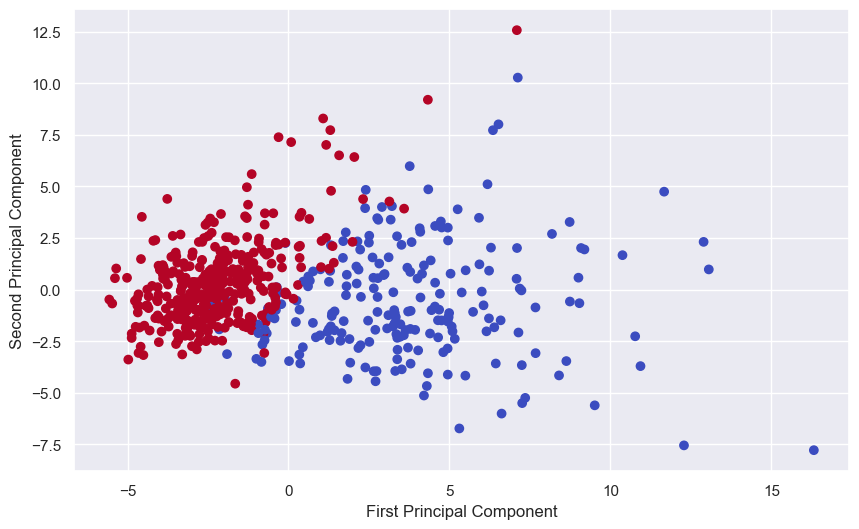

In [16]:
sns.set_theme()
plt.figure(figsize=(10,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=df['target'], cmap='coolwarm')
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")

### Interpretting Components

* Just based off the first two components, we can see that there is a very clear separation of what the malignant vs benign tumors look like
* "First" vs "Second" principal components don't correlate to any specific columns but rather a <i><b>combination</b></i> of your features
  * Components themselves are stored as an attribute of the PCA object

In [17]:
# Each row represents a principal component, and each column relates back to the actual features
pca.components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])

In [18]:
df_comp = pd.DataFrame(pca.components_, columns=df['feature_names'])

<Axes: >

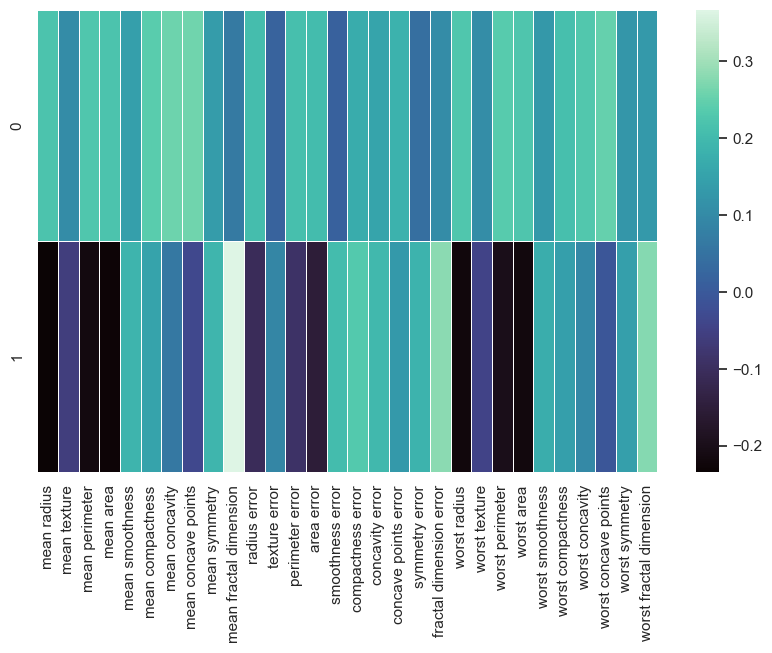

In [19]:
#Heatmap below shows the relationship between the correlation of the various features and the principal components themselves
plt.figure(figsize=(10,6))
sns.heatmap(df_comp, cmap='mako', linewidths=0.5, linecolor='white')

### After PCA (Next steps: Passing PCA features into another ML algorithm)
* You’re not using the original features anymore. You’re using the principal components as inputs (features) to your model
* Principal components are combinations of your original features, but they don’t have simple, human-readable meanings
* They’re like “blends” of your original columns, oriented in the directions of maximum variance (spread)
* PC1 explains the most variance, and PC2 explains the next most, and is orthogonal to PC1...and so on
* So instead of interpreting what PC1 “means” directly, you interpret your model’s performance or visualization in the reduced space.

<b>How to interpret results?</b>
* You don’t need to interpret PC1/PC2 directly to build a successful model.
* You can inspect the component weights (also called loadings) to see how much each original feature contributed to each component — useful for feature importance, but optional.
* If you reduced to 2D or 3D, you can visualize the data (e.g., scatter plot colored by label) to see patterns or clusters.